# Canonical quantum neurons vs. classical PINNs: screened Poisson equation with a variable coefficient $\lambda(z)$

Same setting as `Canonical_QPINN_Poisson.ipynb`, but the constant $\lambda$ is replaced by a periodic function $\lambda(z)$, so the PDE has no closed-form solution.
Expectation values are computed exactly by statevector simulation; gradients use automatic differentiation.

Explicitly, in terms of $\cos$ and $\sin$ only ($z=(z_1,\dots,z_n)\in[0,2\pi)^n$, periodic, $n=7$ below):

$$
-\Delta u+\Big(\lambda_0+\sum_{q=1}^{n-1}c_q\cos z_q\cos z_{q+1}\Big)\,u
=\sum_{q=1}^{n-1}W_q\cos z_q\cos z_{q+1}+\sum_{q=1}^{n}w_q\sin z_q+b,
$$

with $\lambda_0=2$, $c_q\sim U[0,0.2]$, and $W_q,w_q,b\sim\mathcal N(0,1)$ (8 random instances).

## Problem

On the torus $z\in[0,2\pi)^7$ with periodic boundary conditions:

$$
\boxed{\big(\lambda(z)-\Delta\big)\,u(z)=\mathrm{Tr}\big[H^\star\rho(z)\big],\qquad \lambda(z)=\lambda_0+\sum_{q=1}^{6}c_q\cos z_q\cos z_{q+1}}
$$

$$
\rho(z)=e^{-\frac i2\sum_{q}z_q\sigma_Y^{(q)}}\,|0\rangle\langle0|^{\otimes7}\,e^{\frac i2\sum_{q}z_q\sigma_Y^{(q)}},\qquad
H^\star=\sum_{q=1}^{6}W_q\,Z_qZ_{q+1}+\sum_{q=1}^{7}w_q\,X_q+b\,I,
$$

with $W_q,w_q,b\sim\mathcal N(0,1)$ (8 random instances), $\lambda_0=2$ and $c_q\sim U[0,0.2]$ (fixed, shared by all instances), so $\lambda(z)>0$.
Equivalently $\lambda(z)=\mathrm{Tr}\big[(\lambda_0I+\sum_qc_qZ_qZ_{q+1})\rho(z)\big]$.

This is the static Schrödinger equation $-\Delta u+Vu=f$ (Lu, Lu, Wang, COLT 2021, Eq. (2.2)) with a periodic, nearest-neighbour coupled variant of the cosine potential of Han, Lu, Zhou (J. Comput. Phys. 2020, §3.2).
There is no closed-form solution; the reference solution is computed numerically (Fourier pseudo-spectral method on a $7^7$ grid with conjugate gradients) and is used only to measure the error.

## Models

| Model | Ansatz | Trainable parameters |
|---|---|---|
| Quantum TFIM | $c\,\mathrm{Tr}\big[\tanh(H_{\rm TFIM}(\theta))\rho(z)\big]$, $\ H_{\rm TFIM}=\sum_q W_qZ_qZ_{q+1}+\sum_q w_qX_q+bI$ | 14 |
| Quantum IM | $c\,\mathrm{Tr}\big[\tanh(H_{\rm IM}(\theta))\rho(z)\big]$, $\ H_{\rm IM}=\sum_q W_qZ_qZ_{q+1}+\sum_q w_qZ_q+bI$ | 14 |
| PINN, 1 hidden layer | `nn.Linear(14, 1)` → `Tanh` → `nn.Linear(1, 1)` on $(\cos z,\sin z)\in\mathbb R^{14}$ | 17 |
| PINN, 2 hidden layers | `nn.Linear(14, 1)` → `Tanh` → `nn.Linear(1, 1)` → `Tanh` → `nn.Linear(1, 1)` | 19 |

- The output scale $c=(\sum|W_q|+\sum|w_q|+|b|)/\lambda_{\min}$, $\lambda_{\min}=\lambda_0-\sum_qc_q$, is fixed by the PDE data (it bounds $|u^\star|$ by the maximum principle). Both quantum neurons start from the same $\theta$.
- Quantum residual: $(\lambda(z)-\Delta)\rho(z)=(\lambda(z)+\tfrac n2)\rho(z)-\tfrac12\sum_q\rho(z+\pi e_q)$, so
  $r(z)=c\,\mathrm{Tr}\big[\tanh(H(\theta))\big((\lambda(z)+\tfrac n2)\rho(z)-\tfrac12\sum_q\rho(z+\pi e_q)\big)\big]-\mathrm{Tr}[H^\star\rho(z)]$ uses 8 encoded states per point.
  PINN residuals use automatic differentiation.
- Training: the same 1024 random collocation points for all models, loss $\frac1M\sum_m r(z_m)^2$, Adam with learning rate $10^{-2}\to10^{-4}$ (exponential decay), 500 epochs.
  The 8 instances are trained in parallel as a batch. Errors are measured on 4096 random points of the reference grid.

In [21]:
import math
import time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import qmps as qmp

try:
    import scipy.fft as sfft
    FFT_KW = {"workers": -1}
except ImportError:                               # numpy fallback (slower)
    import numpy.fft as sfft
    FFT_KW = {}

torch.set_default_dtype(torch.float64)
DTYPE = torch.float64
DEVICE = torch.device("cpu")

N_QUBITS = 4                                  # one qubit per coordinate
LAMBDA0, C_MAX = 2.0, 0.2                     # lambda(z) = LAMBDA0 + sum_q c_q cos z_q cos z_{q+1},  c_q ~ U[0, C_MAX]
GRID = 7                                      # reference solver: GRID^7 Fourier grid
N_INSTANCES = 8                               # random H* = independent PDE instances
N_COLLOC = 100
N_TEST = 200
EPOCHS = 500
LR0, LR_MIN = 1e-2, 1e-4
INIT_SCALE = 0.05
PINN_WIDTHS = {"PINN-1": (1,), "PINN-2": (1, 1)}
SEED = 2026

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
NAMES = ["TFIM", "IM", "PINN-1", "PINN-2"]
COLORS = {"TFIM": "#2a78d6", "IM": "#e34948", "PINN-1": "#eda100", "PINN-2": "#1baf7a"}
STYLES = {"TFIM": "-", "IM": "--", "PINN-1": (0, (6, 1.5, 1.5, 1.5)), "PINN-2": ":"}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2.0, "legend.frameon": False,
})

In [22]:
# ---------- models ----------
_PAULI = {
    "I": torch.eye(2, dtype=DTYPE),
    "X": torch.tensor([[0.0, 1.0], [1.0, 0.0]], dtype=DTYPE),
    "Z": torch.tensor([[1.0, 0.0], [0.0, -1.0]], dtype=DTYPE),
}


def pauli_string(label):
    out = torch.ones(1, 1, dtype=DTYPE)
    for ch in label:
        out = torch.kron(out, _PAULI[ch])
    return out


def ising_basis(coupling, field):
    # H(theta) = sum_q W_q C_q C_{q+1} + sum_q w_q F_q + b I, parameters ordered (W_1..W_6, w_1..w_7, b)
    n = N_QUBITS
    labels = ["".join(coupling if k in (q, q + 1) else "I" for k in range(n)) for q in range(n - 1)]
    labels += ["".join(field if k == q else "I" for k in range(n)) for q in range(n)]
    labels += ["I" * n]
    return torch.stack([pauli_string(s) for s in labels])


BASIS = {"TFIM": ising_basis("Z", "X"), "IM": ising_basis("Z", "Z")}
N_H = BASIS["TFIM"].shape[0]                  # 14 parameters


class MatrixTanh(torch.autograd.Function):
    # tanh(H) by eigendecomposition; exact backward (Daleckii-Krein), stable for the degenerate IM spectrum

    @staticmethod
    def forward(ctx, H):
        lam, V = torch.linalg.eigh(H)
        f = torch.tanh(lam)
        ctx.save_for_backward(lam, V, f)
        return (V * f.unsqueeze(-2)) @ V.mT

    @staticmethod
    def backward(ctx, grad_G):
        lam, V, f = ctx.saved_tensors
        dlam = lam.unsqueeze(-1) - lam.unsqueeze(-2)
        deriv = 1.0 - torch.tanh(0.5 * (lam.unsqueeze(-1) + lam.unsqueeze(-2))) ** 2
        close = dlam.abs() < 1e-10
        divided = torch.where(close, deriv, (f.unsqueeze(-1) - f.unsqueeze(-2)) / torch.where(close, torch.ones_like(dlam), dlam))
        sym = 0.5 * (grad_G + grad_G.mT)
        return V @ ((V.mT @ sym @ V) * divided) @ V.mT


class QuantumNeuron(torch.nn.Module):
    # one neuron per PDE instance: u_b(z) = c_b Tr[tanh(H(theta_b)) rho(z)], c_b fixed by the PDE data

    def __init__(self, basis, theta0, scale):
        super().__init__()
        self.register_buffer("basis", basis)
        self.register_buffer("scale", scale.clone())
        self.theta = torch.nn.Parameter(theta0.clone())

    def observable(self):
        return MatrixTanh.apply(torch.einsum("bj,jkl->bkl", self.theta, self.basis))


def pinn_param_count(widths, n=N_QUBITS):
    dims = [2 * n, *widths, 1]
    return sum(o * (i + 1) for i, o in zip(dims[:-1], dims[1:]))


def mlp(widths, n=N_QUBITS):
    # standard tanh network on (cos z, sin z) in R^{2n}: Linear -> Tanh -> ... -> Linear
    layers, d_in = [], 2 * n
    for w in widths:
        layers += [torch.nn.Linear(d_in, w), torch.nn.Tanh()]
        d_in = w
    layers.append(torch.nn.Linear(d_in, 1))
    net = torch.nn.Sequential(*layers)
    for layer in net:
        if isinstance(layer, torch.nn.Linear):
            torch.nn.init.xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)
    return net


class PINN(torch.nn.Module):
    # one independent network per PDE instance: u_b(z) = net_b(cos z, sin z), z in [0, 2pi)^n

    def __init__(self, widths, seed, n=N_QUBITS):
        super().__init__()
        torch.manual_seed(seed)
        self.nets = torch.nn.ModuleList([mlp(widths, n) for _ in range(N_INSTANCES)])

    def forward(self, z):                          # z: (B, N, n) -> (B, N)
        phi = torch.cat([torch.cos(z), torch.sin(z)], dim=-1)
        return torch.stack([net(phi[b])[:, 0] for b, net in enumerate(self.nets)])


N_PARAMS = {**{k: N_H for k in BASIS}, **{k: pinn_param_count(w) for k, w in PINN_WIDTHS.items()}}
LABELS = {
    "TFIM": f"Quantum TFIM ({N_PARAMS['TFIM']} params)",
    "IM": f"Quantum IM ({N_PARAMS['IM']} params)",
    "PINN-1": f"PINN, 1 hidden layer ({N_PARAMS['PINN-1']} params)",
    "PINN-2": f"PINN, 2 hidden layers ({N_PARAMS['PINN-2']} params)",
}

In [23]:
# ---------- encoding and PDE data ----------
def encoded_states(z):
    # |psi(z)> = prod_q RY(z_q)|0>  (real amplitudes)
    lead = z.shape[:-1]
    flat = z.reshape(-1, N_QUBITS)
    state = qmp.State(N_QUBITS, batch_size=flat.shape[0], dtype=DTYPE, device=DEVICE)
    for q in range(N_QUBITS):
        qmp.RY(state, flat[:, q], wires=q)
    return state.real.reshape(*lead, 2**N_QUBITS)


def expectation(G, psi):
    # Tr[G |psi><psi|] for G (B, d, d), psi (N, d) -> (B, N)
    return (torch.einsum("bij,nj->bni", G, psi) * psi).sum(-1)


gen = torch.Generator().manual_seed(SEED)
zeta = torch.randn(N_INSTANCES, N_H, generator=gen)                    # coefficients of the 8 Hamiltonians H*
theta0 = INIT_SCALE * torch.randn(N_INSTANCES, N_H, generator=gen)     # shared initialization of the quantum models
z_col = 2 * math.pi * torch.rand(N_COLLOC, N_QUBITS, generator=gen)
C_LAMBDA = C_MAX * torch.rand(N_QUBITS - 1, generator=torch.Generator().manual_seed(77))
LAMBDA_MIN = LAMBDA0 - C_LAMBDA.sum().item()


def lambda_fn(z):
    return LAMBDA0 + (C_LAMBDA * torch.cos(z[..., :-1]) * torch.cos(z[..., 1:])).sum(-1)


def residual_operator(z):
    # (lambda(z) - Laplacian) rho(z) = (lambda(z) + n/2) rho(z) - 1/2 sum_q rho(z + pi e_q): 8 states per point
    shifts = torch.cat([torch.zeros(1, N_QUBITS), math.pi * torch.eye(N_QUBITS)])
    coef = torch.cat([(lambda_fn(z) + N_QUBITS / 2)[:, None], torch.full((len(z), N_QUBITS), -0.5)], dim=1)
    psi = encoded_states(z[:, None, :] + shifts[None])
    return torch.einsum("mk,mki,mkj->mij", coef, psi, psi)


def rotor_energy(z, params):
    # Tr[H rho(z)] for H = sum W ZZ + sum w X + b I  ->  (B, N)
    W, w, b = params[:, : N_QUBITS - 1], params[:, N_QUBITS - 1 : -1], params[:, -1]
    c, s = torch.cos(z), torch.sin(z)
    return (W[:, None] * c[None, :, :-1] * c[None, :, 1:]).sum(-1) + (w[:, None] * s[None]).sum(-1) + b[:, None]


Sigma = residual_operator(z_col).reshape(N_COLLOC, -1)
lambda_col = lambda_fn(z_col)
f_col = rotor_energy(z_col, zeta)                 # source Tr[H* rho(z)] at the collocation points
scale = zeta.abs().sum(1) / LAMBDA_MIN            # output scale c of the quantum models
print(f"c_q = {np.round(C_LAMBDA.numpy(), 3)},  lambda(z) in [{LAMBDA_MIN:.2f}, {LAMBDA0 + C_LAMBDA.sum():.2f}]")

c_q = [0.067 0.043 0.121],  lambda(z) in [1.77, 2.23]


In [24]:
# ---------- reference solution: Fourier pseudo-spectral method + preconditioned conjugate gradients ----------
def solve_reference(ng, c_lambda=C_LAMBDA, instances=range(N_INSTANCES), tol=1e-11):
    x = 2 * np.pi * np.arange(ng) / ng
    axis = lambda v, q: v.reshape([-1 if d == q else 1 for d in range(N_QUBITS)])
    cos = [axis(np.cos(x), q) for q in range(N_QUBITS)]
    sin = [axis(np.sin(x), q) for q in range(N_QUBITS)]
    lam = LAMBDA0 + sum(float(c_lambda[q]) * cos[q] * cos[q + 1] for q in range(N_QUBITS - 1))
    k = sfft.fftfreq(ng, 1.0 / ng)
    k2 = sum(axis(k, q) ** 2 for q in range(N_QUBITS))
    lam_bar = float(lam.mean())
    apply_op = lambda u: sfft.ifftn(k2 * sfft.fftn(u, **FFT_KW), **FFT_KW).real + lam * u         # (lambda(z) - Lap) u
    precond = lambda r: sfft.ifftn(sfft.fftn(r, **FFT_KW) / (lam_bar + k2), **FFT_KW).real
    sols = []
    for bi in instances:
        W, w, b = zeta[bi, : N_QUBITS - 1].numpy(), zeta[bi, N_QUBITS - 1 : -1].numpy(), zeta[bi, -1].item()
        rhs = np.full([ng] * N_QUBITS, b)
        for q in range(N_QUBITS - 1):
            rhs = rhs + W[q] * cos[q] * cos[q + 1]
        for q in range(N_QUBITS):
            rhs = rhs + w[q] * sin[q]
        u, r = np.zeros_like(rhs), rhs.copy()
        s = precond(r)
        d, rs = s.copy(), np.vdot(r, s)
        for it in range(500):
            Ad = apply_op(d)
            alpha = rs / np.vdot(d, Ad)
            u, r = u + alpha * d, r - alpha * Ad
            if np.linalg.norm(r) < tol * np.linalg.norm(rhs):
                break
            s = precond(r)
            rs_new = np.vdot(r, s)
            d, rs = s + (rs_new / rs) * d, rs_new
        sols.append(u)
    return sols


t0 = time.time()
sols = solve_reference(GRID)
print(f"reference solved in {time.time() - t0:.1f}s")

test_idx = torch.randint(0, GRID, (N_TEST, N_QUBITS), generator=torch.Generator().manual_seed(SEED + 1))
z_test = (2 * math.pi / GRID) * test_idx.to(DTYPE)          # test points = random points of the reference grid
psi_test = encoded_states(z_test)
u_test = torch.stack([torch.tensor(u[tuple(test_idx.T.numpy())]) for u in sols])

reference solved in 0.1s


**Checks.** (1) The 8-state residual operator equals $(\lambda(z)-\Delta)\rho(z)$. (2) For constant $\lambda=\lambda_0$ the solver reproduces the closed-form solution.
(3) Refining the grid from $7^7$ to $9^7$ leaves the solution unchanged (relative difference of the Fourier modes $|k_q|\le3$).

In [25]:
# [1] residual operator vs. automatic differentiation
G = MatrixTanh.apply(torch.einsum("bj,jkl->bkl", zeta[:1], BASIS["TFIM"]))
zr = z_col[:5].clone().requires_grad_(True)
u = expectation(G, encoded_states(zr))[0]
g = torch.autograd.grad(u.sum(), zr, create_graph=True)[0]
lap = sum(torch.autograd.grad(g[:, i].sum(), zr, retain_graph=True)[0][:, i] for i in range(N_QUBITS))
lhs = torch.einsum("mij,ij->m", residual_operator(z_col[:5]), G[0])
print(f"[1] max |Tr[G Sigma] - (lambda(z) - Lap) Tr[G rho]| = {(lhs - (lambda_fn(zr) * u - lap)).abs().max():.1e}")

# [2] constant lambda = lambda0: closed form u* = sum W/(lambda0+2) cos cos + sum w/(lambda0+1) sin + b/lambda0
u0 = solve_reference(GRID, c_lambda=torch.zeros(N_QUBITS - 1), instances=[0])[0]
W, w, b = zeta[:1, : N_QUBITS - 1], zeta[:1, N_QUBITS - 1 : -1], zeta[:1, -1:]
closed = rotor_energy(z_test, torch.cat([W / (LAMBDA0 + 2), w / (LAMBDA0 + 1), b / LAMBDA0], dim=1))[0]
u0_test = torch.tensor(u0[tuple(test_idx.T.numpy())])
print(f"[2] constant lambda, solver vs closed form: relative difference {(torch.linalg.norm(u0_test - closed) / torch.linalg.norm(closed)):.1e}")


# [3] grid refinement 7^7 -> 9^7
def low_modes(u):
    ng = u.shape[0]
    U = sfft.fftn(u, **FFT_KW) / ng**N_QUBITS
    return U[np.ix_(*([np.r_[0:4, ng - 3:ng]] * N_QUBITS))]


fine = solve_reference(9, instances=[0])[0]
print(f"[3] grid 7^7 vs 9^7: relative difference {np.linalg.norm(low_modes(sols[0]) - low_modes(fine)) / np.linalg.norm(low_modes(fine)):.1e}")
del fine

[1] max |Tr[G Sigma] - (lambda(z) - Lap) Tr[G rho]| = 2.0e-15
[2] constant lambda, solver vs closed form: relative difference 3.0e-16
[3] grid 7^7 vs 9^7: relative difference 1.0e-07


In [26]:
# ---------- training ----------
F_MS = f_col.pow(2).mean(1)


def quantum_residual(m):
    G = m.observable()
    return m.scale[:, None] * (G.reshape(N_INSTANCES, -1) @ Sigma.T) - f_col


def quantum_predict(m):
    return m.scale[:, None] * expectation(m.observable(), psi_test)


def pinn_residual(m):
    z = z_col.expand(N_INSTANCES, -1, -1).clone().requires_grad_(True)
    u = m(z)
    grad = torch.autograd.grad(u.sum(), z, create_graph=True)[0]
    lap = sum(torch.autograd.grad(grad[..., i].sum(), z, create_graph=True)[0][..., i] for i in range(N_QUBITS))
    return lambda_col * u - lap - f_col


def pinn_predict(m):
    return m(z_test.expand(N_INSTANCES, -1, -1))


def train(model, residual, predict):
    opt = torch.optim.Adam(model.parameters(), lr=LR0)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda e: (LR_MIN / LR0) ** (min(e, EPOCHS) / EPOCHS))
    losses = []
    for epoch in range(EPOCHS):
        loss = residual(model).pow(2).mean(1)                    # one loss per PDE instance
        losses.append((loss / F_MS).detach())                    # relative PDE residual
        opt.zero_grad()
        loss.sum().backward()
        opt.step()
        sched.step()
    with torch.no_grad():
        error = torch.linalg.norm(predict(model) - u_test, dim=1) / torch.linalg.norm(u_test, dim=1)
    return torch.stack(losses).numpy(), error.numpy()


losses, errors, models = {}, {}, {}
for name in NAMES:
    t0 = time.time()
    if name in BASIS:
        model = QuantumNeuron(BASIS[name], theta0, scale)
        losses[name], errors[name] = train(model, quantum_residual, quantum_predict)
    else:
        model = PINN(PINN_WIDTHS[name], seed=SEED + len(PINN_WIDTHS[name]))
        losses[name], errors[name] = train(model, pinn_residual, pinn_predict)
    models[name] = model
    print(f"{LABELS[name]:40s} {time.time() - t0:5.1f}s | median final residual {np.median(losses[name][-1]):.2e} "
          f"| median rel. L2 error {np.median(errors[name]):.2e}")

Quantum TFIM (8 params)                    0.6s | median final residual 6.79e-04 | median rel. L2 error 1.84e-02
Quantum IM (8 params)                      0.4s | median final residual 5.70e-01 | median rel. L2 error 7.40e-01
PINN, 1 hidden layer (11 params)           4.9s | median final residual 3.27e-01 | median rel. L2 error 4.81e-01
PINN, 2 hidden layers (13 params)          6.5s | median final residual 2.26e-01 | median rel. L2 error 3.89e-01


## Results

PDE residual loss during training (median over the 8 instances, shaded: min–max), the final relative $L^2$ error of each instance, and the learned functions on a 2D slice.

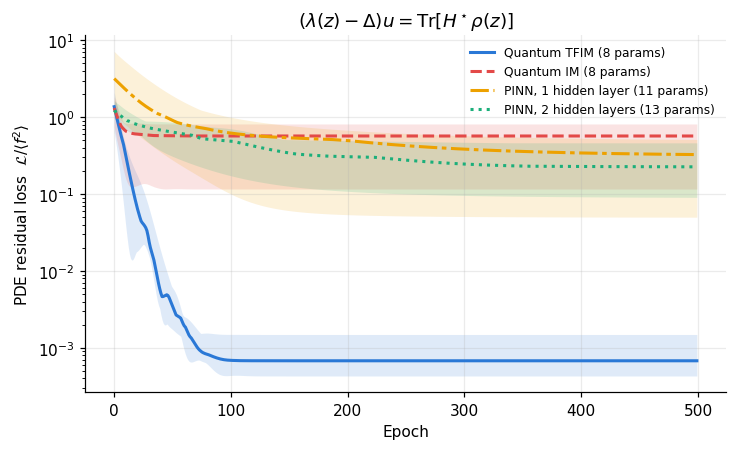

In [27]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
epochs = np.arange(EPOCHS)
for name in NAMES:
    ax.fill_between(epochs, losses[name].min(1), losses[name].max(1), color=COLORS[name], alpha=0.15, lw=0)
    ax.plot(epochs, np.median(losses[name], 1), color=COLORS[name], ls=STYLES[name], label=LABELS[name])
ax.set(yscale="log", xlabel="Epoch", ylabel=r"PDE residual loss  $\mathcal{L}/\langle f^2\rangle$",
       title=r"$(\lambda(z)-\Delta)u=\mathrm{Tr}[H^\star\rho(z)]$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "variable_lambda_residual_loss.png", bbox_inches="tight")
plt.show()

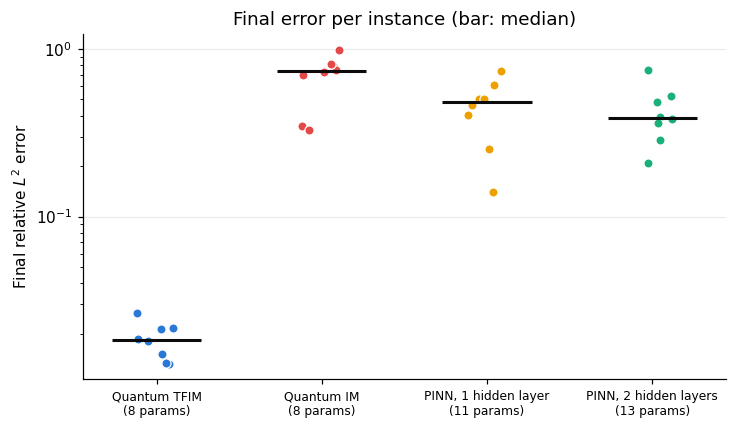

In [28]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
rng = np.random.default_rng(0)
for i, name in enumerate(NAMES):
    y = errors[name]
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(y)), y, s=36, color=COLORS[name], edgecolor="white", linewidth=0.8, zorder=3)
    ax.hlines(np.median(y), i - 0.27, i + 0.27, color="#0b0b0b", lw=2, zorder=4)
ax.set_xticks(range(len(NAMES)), [LABELS[n].replace(" (", "\n(") for n in NAMES], fontsize=8)
ax.set(yscale="log", ylabel=r"Final relative $L^2$ error", title="Final error per instance (bar: median)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "variable_lambda_final_errors.png", bbox_inches="tight")
plt.show()

**Solution slice.** $(z_1,z_2)$ varied, the other five coordinates fixed at random values (instance 0): numerical reference solution
(trigonometric interpolation of the grid solution) and the four approximations.

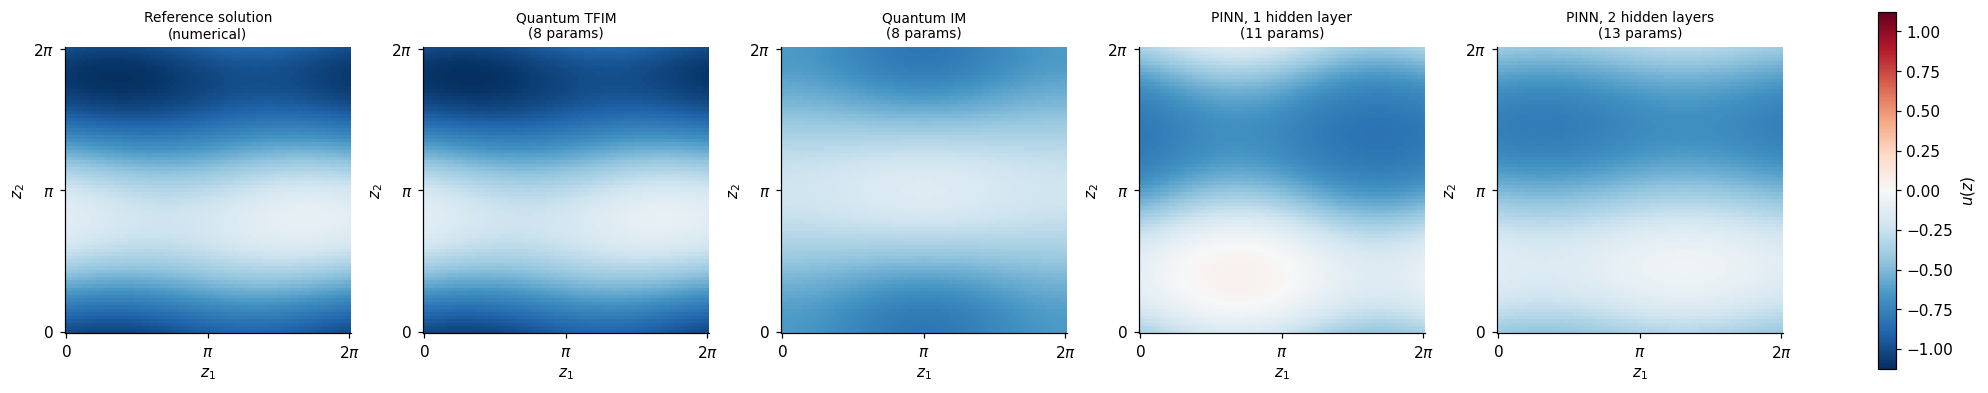

In [29]:
grid_n = 81
axis = torch.linspace(0.0, 2 * math.pi, grid_n)
Z1, Z2 = torch.meshgrid(axis, axis, indexing="ij")
z_fixed = 2 * math.pi * torch.rand(N_QUBITS, generator=torch.Generator().manual_seed(SEED + 7))
z_slice = z_fixed.repeat(grid_n * grid_n, 1)
z_slice[:, 0], z_slice[:, 1] = Z1.reshape(-1), Z2.reshape(-1)
b0 = 0                                            # instance shown


def reference_on_slice(u):
    # trigonometric interpolation of the grid solution on the (z1, z2) plane
    U = sfft.fftn(u, **FFT_KW) / GRID**N_QUBITS
    k = sfft.fftfreq(GRID, 1.0 / GRID)
    for q in range(N_QUBITS - 1, 1, -1):
        U = U @ np.exp(1j * k * z_fixed[q].item())
    E = np.exp(1j * np.outer(axis.numpy(), k))
    return torch.tensor((E @ U @ E.T).real.reshape(-1))


with torch.no_grad():
    U = {"Exact": reference_on_slice(sols[b0])}
    psi_slice = encoded_states(z_slice)
    for name in NAMES:
        m = models[name]
        if name in BASIS:
            U[name] = m.scale[b0] * expectation(m.observable()[b0:b0 + 1], psi_slice)[0]
        else:
            U[name] = m(z_slice.expand(N_INSTANCES, -1, -1))[b0]

titles = {"Exact": "Reference solution\n(numerical)", **{n: LABELS[n].replace(" (", "\n(") for n in NAMES}}
vmax = float(max(v.abs().max() for v in U.values()))
fig, axes = plt.subplots(1, 5, figsize=(18, 3.9), constrained_layout=True)
for ax, key in zip(axes, ["Exact", *NAMES]):
    im = ax.pcolormesh(Z1.numpy(), Z2.numpy(), U[key].reshape(grid_n, grid_n).numpy(),
                       cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    ax.set_title(titles[key], fontsize=9)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xticks([0, math.pi, 2 * math.pi], ["0", r"$\pi$", r"$2\pi$"])
    ax.set_yticks([0, math.pi, 2 * math.pi], ["0", r"$\pi$", r"$2\pi$"])
    ax.set_xlabel(r"$z_1$")
    ax.set_ylabel(r"$z_2$")
fig.colorbar(im, ax=axes, shrink=0.85, label=r"$u(z)$")
fig.savefig(FIG_DIR / "variable_lambda_solution_slice.png", bbox_inches="tight")
plt.show()

## Scaling test: how many PINN parameters are needed to match the TFIM neuron?

For $n=2,\dots,6$ coordinates (= qubits) we solve the same PDE on $[0,2\pi)^n$: $\lambda(z)=\lambda_0+\sum_{q<n}c_q\cos z_q\cos z_{q+1}$, source $\mathrm{Tr}[H^\star\rho(z)]$ with an $n$-qubit TFIM $H^\star$, 8 instances.
The TFIM neuron ($2n$ parameters) is trained for 200 epochs, after which its loss no longer changes. A one-hidden-layer PINN ($(2n+2)\,h+1$ parameters for width $h$)
is then trained for 1000 epochs (at 200 epochs the PINN has not converged yet), starting from $h=1$; $h$ (and hence the number of parameters) is doubled
until the PINN's median error is below the TFIM's (at most $h=1024$). All other settings are as above.
To keep wide networks affordable, the PINN Laplacian is evaluated in closed form (checked against automatic differentiation below).

In [30]:
# # ---------- scaling test ----------
# N_RANGE = range(2, 7)
# EPOCHS_TFIM_SCAN, EPOCHS_PINN_SCAN = 200, 1000
# PINN_START_WIDTH, PINN_MAX_WIDTH = 1, 1024
# 
# 
# def tfim_basis(n):
#     labels = ["".join("Z" if k in (q, q + 1) else "I" for k in range(n)) for q in range(n - 1)]
#     labels += ["".join("X" if k == q else "I" for k in range(n)) for q in range(n)]
#     labels += ["I" * n]
#     return torch.stack([pauli_string(s) for s in labels])
# 
# 
# def encoded_states_n(z, n):
#     lead = z.shape[:-1]
#     flat = z.reshape(-1, n)
#     state = qmp.State(n, batch_size=flat.shape[0], dtype=DTYPE, device=DEVICE)
#     for q in range(n):
#         qmp.RY(state, flat[:, q], wires=q)
#     return state.real.reshape(*lead, 2**n)
# 
# 
# def pcg(apply_A, rhs, precond, tol=1e-11, maxit=500):
#     u, r = np.zeros_like(rhs), rhs.copy()
#     s = precond(r)
#     d, rs = s.copy(), np.vdot(r, s)
#     for _ in range(maxit):
#         Ad = apply_A(d)
#         alpha = rs / np.vdot(d, Ad)
#         u, r = u + alpha * d, r - alpha * Ad
#         if np.linalg.norm(r) < tol * np.linalg.norm(rhs):
#             break
#         s = precond(r)
#         rs_new = np.vdot(r, s)
#         d, rs = s + (rs_new / rs) * d, rs_new
#     return u
# 
# 
# def make_problem_n(n):
#     # the PDE of this notebook on n coordinates (= n qubits)
#     gen = torch.Generator().manual_seed(SEED)
#     zeta_n = torch.randn(N_INSTANCES, 2 * n, generator=gen)
#     theta0_n = INIT_SCALE * torch.randn(N_INSTANCES, 2 * n, generator=gen)
#     z_c = 2 * math.pi * torch.rand(N_COLLOC, n, generator=gen)
#     c_n = C_MAX * torch.rand(n, generator=torch.Generator().manual_seed(77))
#     c_n = c_n[: n - 1]
#     lam_fn = lambda z: LAMBDA0 + (c_n * torch.cos(z[..., :-1]) * torch.cos(z[..., 1:])).sum(-1)
#     W, w, b = zeta_n[:, : n - 1], zeta_n[:, n - 1 : -1], zeta_n[:, -1]
#     source = lambda z: ((W[:, None] * torch.cos(z[None, :, :-1]) * torch.cos(z[None, :, 1:])).sum(-1)
#                         + (w[:, None] * torch.sin(z[None])).sum(-1) + b[:, None])
#     # residual operator: (lambda(z) + n/2) rho(z) - 1/2 sum_q rho(z + pi e_q)
#     shifts = torch.cat([torch.zeros(1, n), math.pi * torch.eye(n)])
#     coef = torch.cat([(lam_fn(z_c) + n / 2)[:, None], torch.full((N_COLLOC, n), -0.5)], dim=1)
#     psi = encoded_states_n(z_c[:, None, :] + shifts[None], n)
#     Sigma_n = torch.einsum("mk,mki,mkj->mij", coef, psi, psi).reshape(N_COLLOC, -1)
#     # reference solution on the GRID^n grid (Fourier pseudo-spectral + PCG)
#     x = 2 * np.pi * np.arange(GRID) / GRID
#     axis_q = lambda v, q: v.reshape([-1 if d == q else 1 for d in range(n)])
#     cos = [axis_q(np.cos(x), q) for q in range(n)]
#     sin = [axis_q(np.sin(x), q) for q in range(n)]
#     lam_g = LAMBDA0 + sum(float(c_n[q]) * cos[q] * cos[q + 1] for q in range(n - 1))
#     k2 = sum(axis_q(sfft.fftfreq(GRID, 1.0 / GRID), q) ** 2 for q in range(n))
#     lam_bar = float(lam_g.mean())
#     apply_op = lambda u: sfft.ifftn(k2 * sfft.fftn(u, **FFT_KW), **FFT_KW).real + lam_g * u
#     precond = lambda r: sfft.ifftn(sfft.fftn(r, **FFT_KW) / (lam_bar + k2), **FFT_KW).real
#     idx = torch.randint(0, GRID, (N_TEST, n), generator=torch.Generator().manual_seed(SEED + 1))
#     u_t = []
#     for bi in range(N_INSTANCES):
#         rhs = np.full([GRID] * n, b[bi].item())
#         for q in range(n - 1):
#             rhs = rhs + W[bi, q].item() * cos[q] * cos[q + 1]
#         for q in range(n):
#             rhs = rhs + w[bi, q].item() * sin[q]
#         u = pcg(apply_op, rhs, precond)
#         u_t.append(torch.tensor(u[tuple(idx.T.numpy())]))
#     z_t = (2 * math.pi / GRID) * idx.to(DTYPE)
#     return {"n": n, "theta0": theta0_n, "scale": zeta_n.abs().sum(1) / (LAMBDA0 - c_n.sum().item()),
#             "z_col": z_c, "lam_col": lam_fn(z_c), "f": source(z_c), "Sigma": Sigma_n,
#             "z_test": z_t, "psi_test": encoded_states_n(z_t, n), "u_test": torch.stack(u_t)}
# 
# 
# def fit(model, residual, predict, P, epochs):
#     opt = torch.optim.Adam(model.parameters(), lr=LR0)
#     sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda e: (LR_MIN / LR0) ** (min(e, epochs) / epochs))
#     for _ in range(epochs):
#         loss = residual(model, P).pow(2).mean(1)
#         opt.zero_grad()
#         loss.sum().backward()
#         opt.step()
#         sched.step()
#     with torch.no_grad():
#         err = torch.linalg.norm(predict(model, P) - P["u_test"], dim=1) / torch.linalg.norm(P["u_test"], dim=1)
#     return float(np.median(err.numpy()))
# 
# 
# def tfim_res(m, P):
#     return m.scale[:, None] * (m.observable().reshape(N_INSTANCES, -1) @ P["Sigma"].T) - P["f"]
# 
# 
# def tfim_pred(m, P):
#     return m.scale[:, None] * expectation(m.observable(), P["psi_test"])
# 
# 
# def pinn_value_laplacian(m, z):
#     # exact value and Laplacian of a one-hidden-layer PINN u = a . tanh(V phi(z) + c) + d, phi = (cos z, sin z),
#     # written out analytically (same result as autograd, but much faster and lighter for wide networks)
#     n = z.shape[-1]
#     W1 = torch.stack([net[0].weight for net in m.nets])             # (B, h, 2n)
#     b1 = torch.stack([net[0].bias for net in m.nets])               # (B, h)
#     a = torch.stack([net[2].weight[0] for net in m.nets])           # (B, h)
#     d = torch.stack([net[2].bias for net in m.nets])                # (B, 1)
#     Vc, Vs = W1[..., :n], W1[..., n:]
#     cz, sz = torch.cos(z), torch.sin(z)                             # (B, N, n)
#     lin = torch.einsum("bni,bhi->bnh", cz, Vc) + torch.einsum("bni,bhi->bnh", sz, Vs)
#     t = torch.tanh(lin + b1[:, None, :])
#     grad2 = (torch.einsum("bni,bhi->bnh", cz**2, Vs**2) + torch.einsum("bni,bhi->bnh", sz**2, Vc**2)
#              - 2 * torch.einsum("bni,bhi->bnh", sz * cz, Vs * Vc))   # |grad of the pre-activation|^2
#     lap_t = -2 * t * (1 - t**2) * grad2 - (1 - t**2) * lin          # Laplacian of tanh(pre-activation)
#     return torch.einsum("bnh,bh->bn", t, a) + d, torch.einsum("bnh,bh->bn", lap_t, a)
# 
# 
# def pinn_res(m, P):
#     u, lap = pinn_value_laplacian(m, P["z_col"].expand(N_INSTANCES, -1, -1))
#     return P["lam_col"] * u - lap - P["f"]
# 
# 
# def pinn_pred(m, P):
#     return m(P["z_test"].expand(N_INSTANCES, -1, -1))
# 
# 
# # check: analytic Laplacian of the one-hidden-layer PINN = automatic differentiation
# _m = PINN((4,), seed=0, n=3)
# _z = (2 * math.pi * torch.rand(5, 3, generator=torch.Generator().manual_seed(1))).expand(N_INSTANCES, -1, -1).clone().requires_grad_(True)
# _u = _m(_z)
# _g = torch.autograd.grad(_u.sum(), _z, create_graph=True)[0]
# _lap = sum(torch.autograd.grad(_g[..., i].sum(), _z, retain_graph=True)[0][..., i] for i in range(3))
# _u2, _lap2 = pinn_value_laplacian(_m, _z.detach())
# print(f"check: analytic vs autograd PINN Laplacian, max difference {(_lap - _lap2).abs().max():.1e}; value {(_u - _u2).abs().max():.1e}")
# 
# scan = []
# for n in N_RANGE:
#     t0 = time.time()
#     P = make_problem_n(n)
#     e_tfim = fit(QuantumNeuron(tfim_basis(n), P["theta0"], P["scale"]), tfim_res, tfim_pred, P, EPOCHS_TFIM_SCAN)
#     print(f"n = {n}: TFIM ({2 * n} params) median error {e_tfim:.3e}")
#     width = PINN_START_WIDTH
#     while True:
#         e_pinn = fit(PINN((width,), seed=SEED + width, n=n), pinn_res, pinn_pred, P, EPOCHS_PINN_SCAN)
#         n_par = pinn_param_count((width,), n)
#         print(f"       PINN width {width:5d} ({n_par:6d} params) median error {e_pinn:.3e}")
#         if e_pinn < e_tfim or width >= PINN_MAX_WIDTH:
#             break
#         width *= 2
#     scan.append({"n": n, "tfim_params": 2 * n, "tfim_error": e_tfim, "pinn_params": n_par, "pinn_error": e_pinn,
#                  "matched": e_pinn < e_tfim})
#     print(f"       ({time.time() - t0:.0f}s)")
# 
# print(f"\n{'n':>2s} | {'TFIM params':>11s} {'TFIM error':>10s} | {'PINN params needed':>18s} {'PINN error':>10s}")
# for r in scan:
#     need = f"{r['pinn_params']:d}" if r["matched"] else f">{r['pinn_params']:d}"
#     print(f"{r['n']:2d} | {r['tfim_params']:11d} {r['tfim_error']:10.2e} | {need:>18s} {r['pinn_error']:10.2e}")
# 
# fig, ax = plt.subplots(figsize=(6.0, 4.0))
# ns = [r["n"] for r in scan]
# ax.plot(ns, [r["pinn_params"] for r in scan], color=COLORS["PINN-1"], marker="o", label="PINN (1 hidden layer) needed to match TFIM")
# ax.plot(ns, [r["tfim_params"] for r in scan], color=COLORS["TFIM"], marker="*", ms=10, label="Quantum TFIM")
# for r in scan:
#     if not r["matched"]:
#         ax.annotate("not reached", (r["n"], r["pinn_params"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
# ax.set(yscale="log", xlabel="Number of qubits / coordinates n", ylabel="Number of trainable parameters",
#        title=f"Parameters for equal accuracy (TFIM {EPOCHS_TFIM_SCAN}, PINN {EPOCHS_PINN_SCAN} epochs)")
# ax.set_xticks(ns)
# ax.legend(fontsize=8.5)
# fig.tight_layout()
# fig.savefig(FIG_DIR / "variable_lambda_pinn_params_scaling.png", bbox_inches="tight")
# plt.show()